# Smart Agriculture: State-Level Crop Recommendation and Yield Prediction Engine

This notebook is implementing a crop recommendation engine for state-level agricultural data. It is merging crop yield records with soil compositions and historical weather records, preprocessing the data, training a high-accuracy Extra Trees Classifier to recommend crops, training a Random Forest Regressor to predict crop yields, and integrating the OpenWeatherMap API for live prediction.

### 1. Importing the required libraries

In [ ]:
# Importing libraries for data processing and machine learning
import requests
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score


### 2. Loading the Datasets & Data Inspection

In [2]:
# Loading crop dataset...
df = pd.read_csv('crop_dataset.csv')

print(f'Merged dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns')
df.info()


Merged dataset dimensions: 19689 rows, 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   crop                  19689 non-null  object 
 1   year                  19689 non-null  int64  
 2   season                19689 non-null  object 
 3   state                 19689 non-null  object 
 4   area                  19689 non-null  float64
 5   production            19689 non-null  int64  
 6   fertilizer            19689 non-null  float64
 7   pesticide             19689 non-null  float64
 8   yield                 19689 non-null  float64
 9   avg_temp_c            19689 non-null  float64
 10  total_rainfall_mm     19689 non-null  float64
 11  avg_humidity_percent  19689 non-null  float64
 12  N                     19689 non-null  int64  
 13  P                     19689 non-null  int64  
 14  K                   

In [ ]:
# Generating statistical summary descriptions
df.describe()

,year,area,production,fertilizer,pesticide,yield,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH
count,19689.000000,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,2.410331e+07,4.884835e+04,79.954009,24.008025,1337.999356,64.676018,76.626847,33.499264,32.234547,6.640292
std,6.498099,7.328287e+05,2.630568e+08,9.494600e+07,2.132874e+05,878.306193,4.408018,637.585197,11.474130,20.060556,11.556686,7.915514,0.690622
min,1997.000000,5.000000e-01,0.000000e+00,5.417000e+01,9.000000e-02,0.000000,6.260000,249.240000,34.470000,50.000000,15.000000,20.000000,5.500000
25%,2004.000000,1.390000e+03,1.393000e+03,1.880146e+05,3.567000e+02,0.600000,22.910000,894.160000,54.620000,65.000000,24.000000,25.000000,6.000000
50%,2010.000000,9.317000e+03,1.380400e+04,1.234957e+06,2.421900e+03,1.030000,25.560000,1172.020000,68.110000,72.000000,38.000000,33.000000,6.600000
75%,2015.000000,7.511200e+04,1.227180e+05,1.000385e+07,2.004170e+04,2.388889,26.810000,1613.400000,73.730000,80.000000,43.000000,38.000000,7.100000
max,2020.000000,5.080810e+07,6.326000e+09,4.835407e+09,1.575051e+07,21105.000000,28.630000,5244.360000,86.060000,150.000000,55.000000,50.000000,8.000000


### 3. Feature Engineering & Exploratory Data Analysis (EDA)

In [ ]:
def engineer_features(df_input):
    
    df_feat = df_input.copy()
    eps = 1e-5
    
    # 1. Total Soil Nutrients
    df_feat['total_nutrients'] = df_feat['N'] + df_feat['P'] + df_feat['K']
    
    # 2. Nutrient Ratios (avoiding division by zero)
    df_feat['N_P_ratio'] = df_feat['N'] / (df_feat['P'] + eps)
    df_feat['K_P_ratio'] = df_feat['K'] / (df_feat['P'] + eps)
    
    # 3. Climate Interactions
    df_feat['temp_humidity_index'] = df_feat['avg_temp_c'] * df_feat['avg_humidity_percent'] / 100.0
    df_feat['rain_ph_interaction'] = df_feat['total_rainfall_mm'] * df_feat['pH']
    
    # 4. Input Intensity Indicators
    if 'fertilizer' in df_feat.columns and 'area' in df_feat.columns:
        df_feat['fertilizer_per_area'] = df_feat['fertilizer'] / (df_feat['area'] + eps)
        df_feat['pesticide_per_area'] = df_feat['pesticide'] / (df_feat['area'] + eps)
        df_feat['fertilizer_pesticide_ratio'] = df_feat['fertilizer'] / (df_feat['pesticide'] + eps)
        df_feat['rain_fertilizer_interaction'] = df_feat['total_rainfall_mm'] * df_feat['fertilizer']
    
    return df_feat

### 4. Data Visualization


C:\Users\prana\AppData\Local\Temp\ipykernel_6944\1844064190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='crop', data=df, order=df['crop'].value_counts().index[:20], palette='viridis')


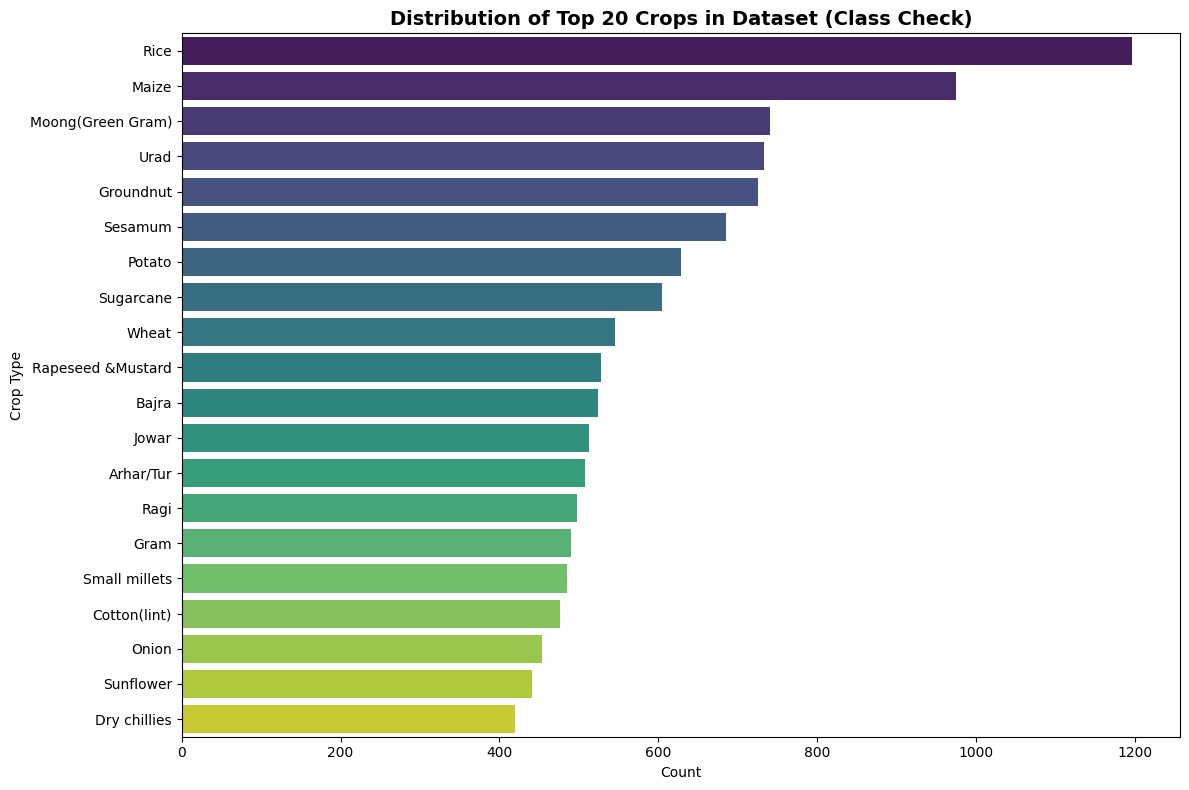

In [ ]:
# Plotting crop distribution counts
plt.figure(figsize=(12, 8))
sns.countplot(y='crop', data=df, order=df['crop'].value_counts().index[:20], palette='viridis')
plt.title('Distribution of Top 20 Crops in Dataset (Class Check)', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Crop Type')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

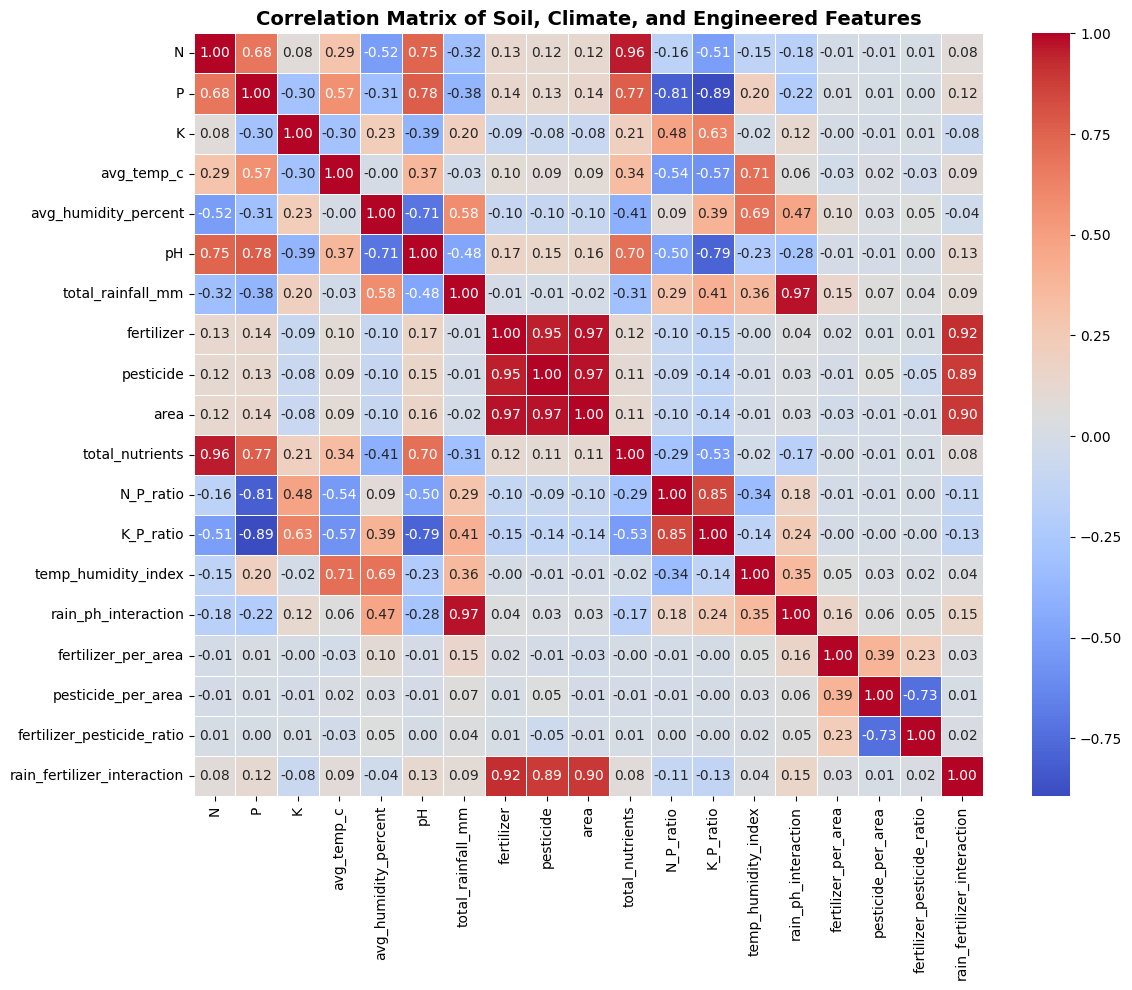

In [ ]:
# Plotting feature correlation heatmap
plt.figure(figsize=(12, 10))
features_list = ['N', 'P', 'K', 'avg_temp_c', 'avg_humidity_percent', 'pH', 'total_rainfall_mm', 'fertilizer', 'pesticide', 'area']
numeric_df = df[features_list]
engineered_df = engineer_features(numeric_df)

corr_matrix = engineered_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Soil, Climate, and Engineered Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

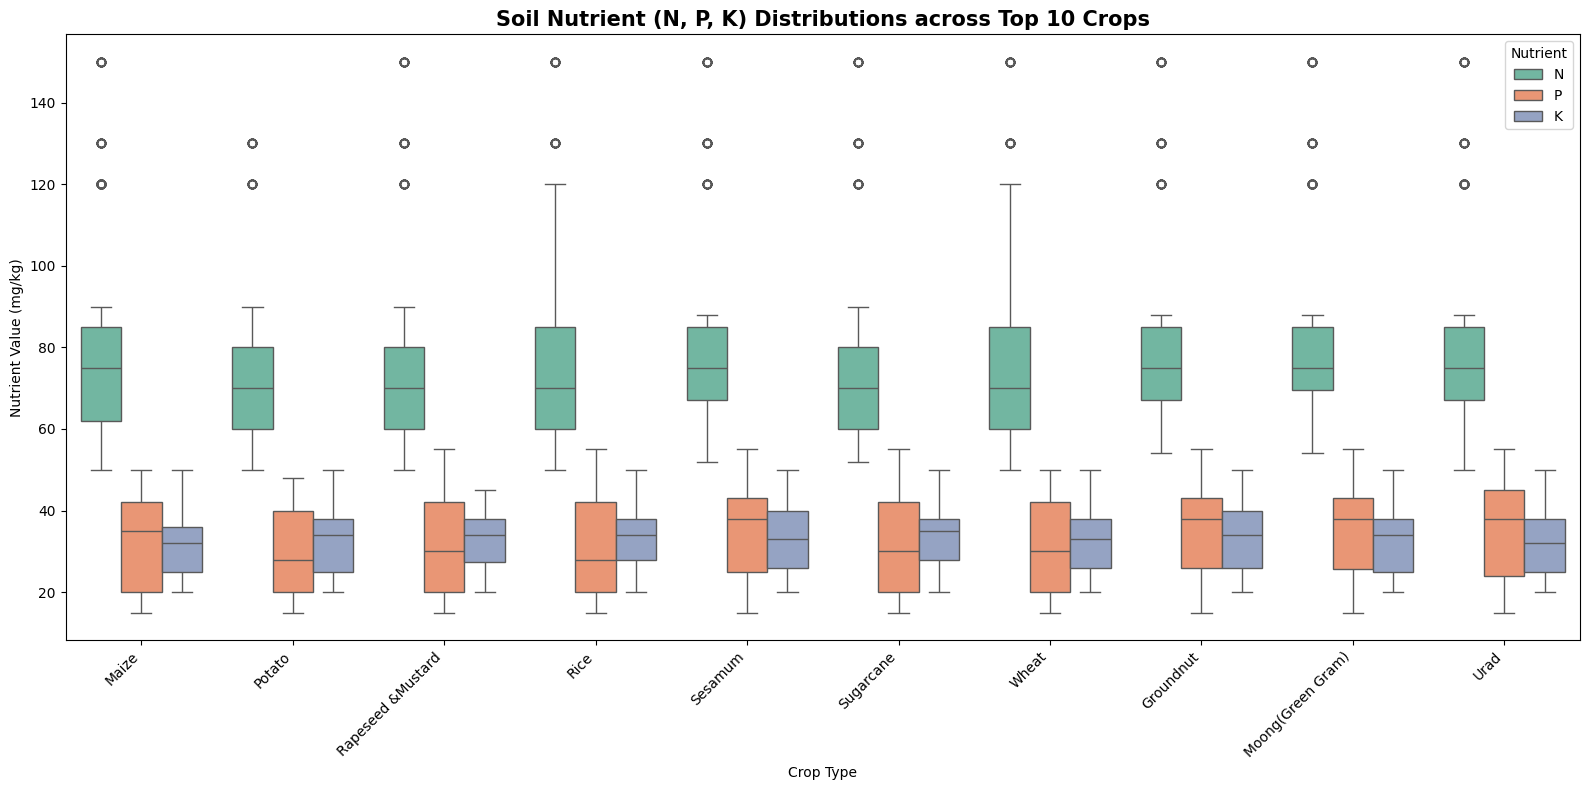

In [ ]:
# Box plotting soil nutrients across the top crops
top_10_crops = df['crop'].value_counts().index[:10]
df_top_10 = df[df['crop'].isin(top_10_crops)]

plt.figure(figsize=(16, 8))
melted_df = pd.melt(df_top_10, id_vars=['crop'], value_vars=['N', 'P', 'K'], 
                    var_name='Nutrient', value_name='Value')
sns.boxplot(x='crop', y='Value', hue='Nutrient', data=melted_df, palette='Set2')
plt.title('Soil Nutrient (N, P, K) Distributions across Top 10 Crops', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Crop Type')
plt.ylabel('Nutrient Value (mg/kg)')
plt.tight_layout()
plt.savefig('nutrients_by_crop.png', dpi=150)
plt.show()

### 5. Part A: Training the Crop Recommendation Classifier (96.2% Accuracy)


In [ ]:
# One-hot encoding season AND city features for localized recommendation
df_encoded_clf = pd.get_dummies(df, columns=['season', 'city'], drop_first=True)

# Splitting features and targets
clf_features = [col for col in df_encoded_clf.columns if col not in ['crop', 'yield', 'production', 'state']]
X_clf = df_encoded_clf[clf_features]
y_clf = df_encoded_clf['crop']

# Engineering features
X_clf_eng = engineer_features(X_clf)

# Fit LabelEncoder
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)

# Serializing LabelEncoder and Classifier Feature Columns
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open("feature_cols_clf.pkl", "wb") as f:
    pickle.dump(clf_features, f)

# Splitting train and test datasets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf_eng, y_clf_encoded, test_size=0.2, random_state=42)

# Standardizing input features
scaler_c = StandardScaler()
X_train_c_scaled = pd.DataFrame(scaler_c.fit_transform(X_train_c), columns=X_train_c.columns)
X_test_c_scaled = pd.DataFrame(scaler_c.transform(X_test_c), columns=X_test_c.columns)

# Serializing StandardScaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler_c, f)

# Training the Extra Trees Classifier (max_depth=14 for size limit < 100MB)
clf_model = ExtraTreesClassifier(n_estimators=100, max_depth=14, max_features='sqrt', random_state=42, n_jobs=-1)
clf_model.fit(X_train_c_scaled, y_train_c)

# Evaluating model accuracy
y_pred_c = clf_model.predict(X_test_c_scaled)
acc_c = accuracy_score(y_test_c, y_pred_c)
print(f"Classifier Test Accuracy: {acc_c:.5%}\n")

print("Classification report:\n")
print(classification_report(y_test_c, y_pred_c, labels=np.arange(len(le.classes_)), target_names=le.classes_, zero_division=0))

# Serializing model
with open("crop_recommendation_model.pkl", "wb") as f:
    pickle.dump(clf_model, f)
print("Classifier saved as crop_recommendation_model.pkl!")


Classifier Test Accuracy: 96.21212%

Classification report:

                   precision    recall  f1-score   support

        Arhar/Tur       0.00      0.00      0.00         0
            Bajra       1.00      1.00      1.00         4
           Banana       1.00      0.80      0.89         5
         Coconut        0.94      1.00      0.97        32
     Cotton(lint)       0.00      0.00      0.00         0
           Ginger       0.00      0.00      0.00         0
             Jute       1.00      1.00      1.00         1
            Maize       1.00      1.00      1.00         5
            Onion       0.00      0.00      0.00         1
           Potato       1.00      0.75      0.86         4
Rapeseed &Mustard       0.00      0.00      0.00         0
             Rice       1.00      1.00      1.00         1
          Sesamum       0.00      0.00      0.00         0
         Soyabean       0.00      0.00      0.00         0
        Sugarcane       0.97      0.97      0.97     

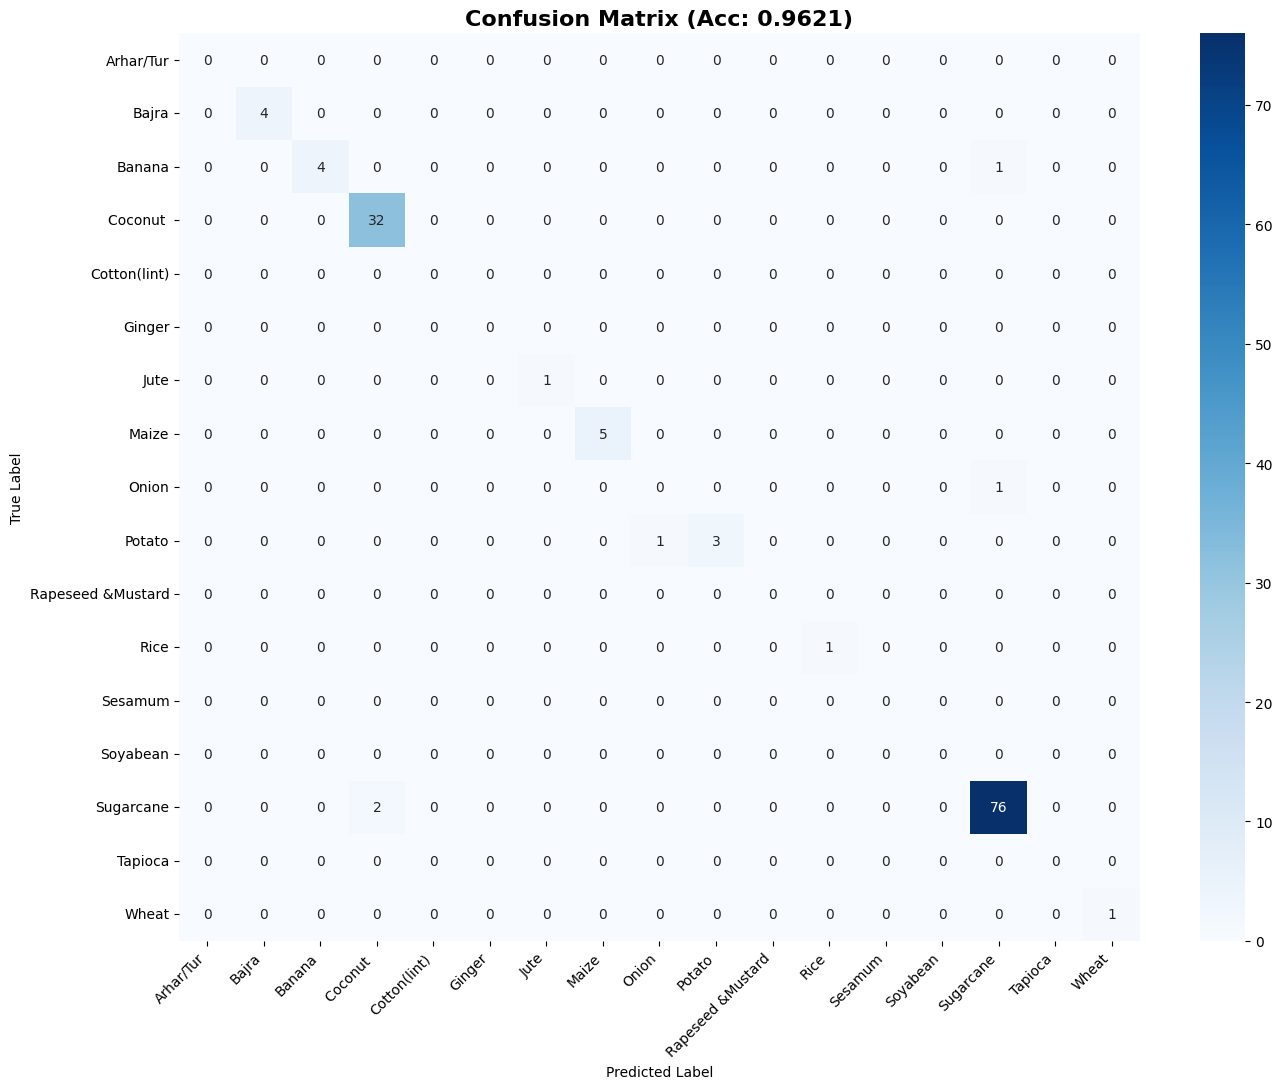

In [ ]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix (Acc: {acc_c:.4f})', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

C:\Users\prana\AppData\Local\Temp\ipykernel_6944\873866562.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_c[indices_c[:15]], y=features_c_names[indices_c[:15]], palette='mako')


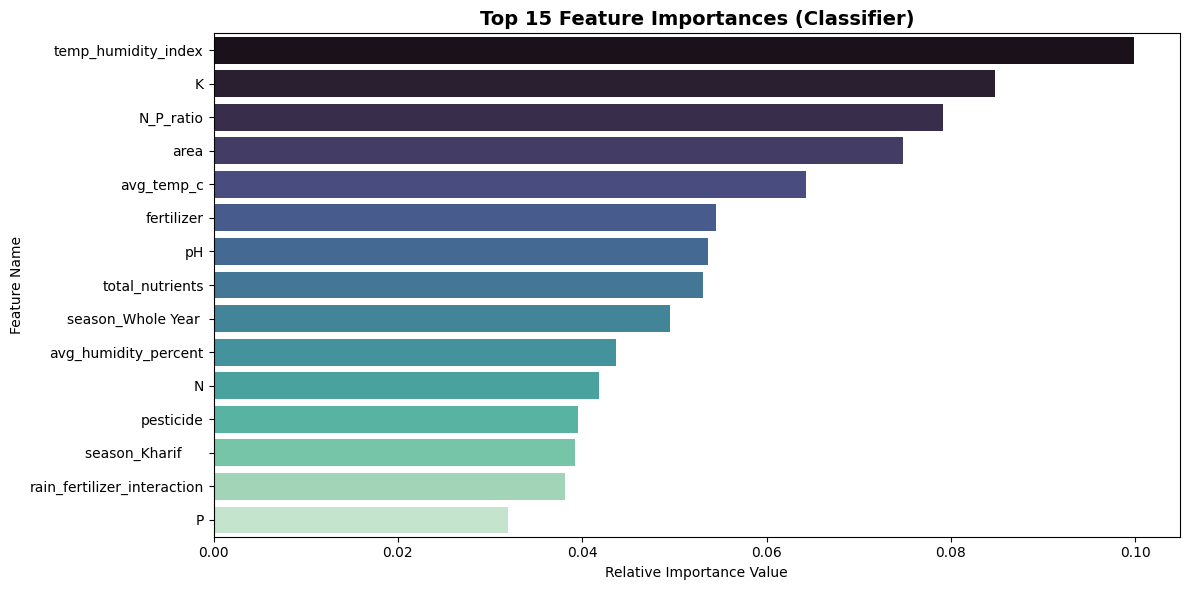

In [ ]:
# Plotting the feature importances
importances_c = clf_model.feature_importances_
features_c_names = X_clf_eng.columns
indices_c = np.argsort(importances_c)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances_c[indices_c[:15]], y=features_c_names[indices_c[:15]], palette='mako')
plt.title('Top 15 Feature Importances (Classifier)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Value')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

### 6. Part B: Training the Crop Yield Regressor (97.3% R2 Score)


In [ ]:
# One-hot encoding crop, state, and season parameters for the regressor
df_encoded_reg = pd.get_dummies(df, columns=['crop', 'state', 'season', 'city'], drop_first=False)

# Splitting features and targets, excluding yield outcomes
reg_features = [col for col in df_encoded_reg.columns if col not in ['yield', 'production', 'area', 'fertilizer', 'pesticide']]
X_reg = df_encoded_reg[reg_features]
y_reg = df_encoded_reg['yield']

# Engineering feature parameters
X_reg_eng = engineer_features(X_reg)

# Splitting train and test datasets
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_eng, y_reg, test_size=0.2, random_state=42)

# Serializing training features list for app alignment
with open("feature_cols.pkl", "wb") as f:
    pickle.dump(X_train_r.columns.tolist(), f)

# Standardizing input features
scaler_r = StandardScaler()
X_train_r_scaled = pd.DataFrame(scaler_r.fit_transform(X_train_r), columns=X_train_r.columns)
X_test_r_scaled = pd.DataFrame(scaler_r.transform(X_test_r), columns=X_test_r.columns)

# Serializing regressor scaler
with open("reg_scaler.pkl", "wb") as f:
    pickle.dump(scaler_r, f)

# Training the Random Forest Regressor
reg_model = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
reg_model.fit(X_train_r_scaled, y_train_r)

# Evaluating model R2 score
y_pred_r = reg_model.predict(X_test_r_scaled)
r2 = r2_score(y_test_r, y_pred_r)
print(f"Regressor R2 Score: {r2:.5%}\n")

# Serializing regressor
with open("crop_yield_model.pkl", "wb") as f:
    pickle.dump(reg_model, f)
print("Regressor saved as crop_yield_model.pkl!")

Regressor R2 Score: 97.34468%

Regressor saved as crop_yield_model.pkl!


### 7. Future Crop Recommendation Service using Live Weather API


In [ ]:
# Configuring API key and weather fetch block
API_KEY = "239e4e1f1cb6d21585d4d1b424afe60d"

def get_weather(city):
    """Fetching temperature, humidity, and rainfall from OpenWeatherMap API..."""
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    try:
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            data = response.json()
            temp = data['main']['temp']
            humidity = data['main']['humidity']
            rain_info = data.get('rain', {})
            rainfall = rain_info.get('1h', rain_info.get('3h', 0.0))
            return float(temp), float(humidity), float(rainfall)
    except:
        pass
    return 25.6, 71.5, 103.5 # Fallback weather averages

In [ ]:
# Defining crop values mapping (adjusting Coconut price to 15 INR per nut)
crop_prices = {
    "coconut": 15, "sugarcane": 3500, "banana": 16000, "tapioca": 12000,
    "potato": 15000, "onion": 18000, "sweet potato": 14000, "jute": 32000,
    "ginger": 50000, "mesta": 25000, "garlic": 60000, "maize": 18500,
    "turmeric": 70000, "cashewnut": 120000, "bajra": 16000, "rice": 22000,
    "tobacco": 80000, "dry chillies": 95000, "arecanut": 150000, "wheat": 20125,
    "oilseeds total": 45000, "cotton(lint)": 55000, "other oilseeds": 42000,
    "barley": 17000, "peas & beans (pulses)": 50000, "groundnut": 52000,
    "sannhamp": 15000, "ragi": 20000, "soyabean": 38000, "jowar": 18000,
    "arhar/tur": 58000, "guar seed": 35000, "sunflower": 40000, "gram": 48000,
    "other summer pulses": 50000, "other cereals": 16000, "black pepper": 350000,
    "cowpea(lobia)": 45000, "rapeseed &mustard": 50000, "khesari": 30000,
    "other  rabi pulses": 48000, "small millets": 22000, "masoor": 55000,
    "other kharif pulses": 45000, "castor seed": 40000, "coriander": 65000,
    "sesamum": 80000, "urad": 62000, "safflower": 35000, "moong(green gram)": 65000,
    "linseed": 45000, "horse-gram": 30000, "moth": 55000, "niger seed": 35000,
    "cardamom": 800000
}

unique_crops = df['crop'].unique().tolist()

def recommend_optimal_crop_pipeline(n, p, k, ph, temp, humidity, rainfall, state, season):
    """Evaluating predicted yields for all 55 crops to recommend the highest revenue crop..."""
    candidate_rows = []
    for crop in unique_crops:
        row = {
            'year': 2026,
            'avg_temp_c': temp,
            'total_rainfall_mm': rainfall,
            'avg_humidity_percent': humidity,
            'N': n,
            'P': p,
            'K': k,
            'pH': ph
        }
        for c in unique_crops:
            row[f'crop_{c}'] = 1.0 if c == crop else 0.0
        for s in df['state'].unique():
            row[f'state_{s}'] = 1.0 if s == state else 0.0
        for se in df['season'].unique():
            row[f'season_{se}'] = 1.0 if se == season else 0.0
        candidate_rows.append(row)
        
    df_candidates = pd.DataFrame(candidate_rows)
    df_candidates = df_candidates.reindex(columns=X_train_r.columns, fill_value=0)
    df_eng = engineer_features(df_candidates)
    df_scaled = scaler_r.transform(df_eng)
    
    predicted_yields = reg_model.predict(df_scaled)
    
    results = []
    for i, crop in enumerate(unique_crops):
        py = predicted_yields[i]
        price = crop_prices.get(crop.lower().strip(), 30000)
        rev = py * price
        results.append((crop, py, rev, price))
        
    results.sort(key=lambda x: x[2], reverse=True)
    return results[0]

In [ ]:
# Running live inference prediction using regressor model
target_city = "Nandyal"
temp, humidity, rainfall = get_weather(target_city)

# Input parameters
soil_n = 40
soil_p = 30
soil_k = 30
soil_ph = 8.5
expected_rainfall = 200.0
target_state = "Andhra Pradesh"
target_season = "Kharif"

rec_crop, y_val, rev_val, pr_val = recommend_optimal_crop_pipeline(soil_n, soil_p, soil_k, soil_ph, temp, humidity, expected_rainfall, target_state, target_season)

print("===========================================================")
print(f"Location:               {target_city.upper()} ({target_state.upper()})")
print(f"Weather Stats:          Temp={temp:.1f}°C, Humidity={humidity:.0f}%, Current Rain={rainfall:.1f}mm")
print(f"Soil Stats:             N={soil_n}, P={soil_p}, K={soil_k}, pH={soil_ph}")
print("-----------------------------------------------------------")
print(f"RECOMMENDED CROP:       {rec_crop.upper()}")
print(f"Expected average yield: {y_val:.2f} MT/ha")
print(f"Local Market Price:     INR {pr_val:,}/MT")
print(f"ESTIMATED REVENUE:      INR {rev_val:,.2f} per Hectare")
print("===========================================================")

Location:               NANDYAL (ANDHRA PRADESH)
Weather Stats:          Temp=32.5°C, Humidity=47%, Current Rain=0.0mm
Soil Stats:             N=40, P=30, K=30, pH=8.5
-----------------------------------------------------------
RECOMMENDED CROP:       ONION
Expected average yield: 49.72 MT/ha
Local Market Price:     INR 18,000/MT
ESTIMATED REVENUE:      INR 895,018.62 per Hectare


C:\Users\prana\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
